In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.utils import resample

import joblib
import os


## Train on ORCA data from Mateo et al. (2019) using experiments

### Read data

In [218]:
# Read features
dist_data = pd.read_csv('../data/Mateo_2019/selected_structures_75_5000_filtered.tsv', sep='\t')

# Read transcriptional data
transc_data = pd.read_csv('../data/Mateo_2019/transcriptional_data_75_5000_filtered.tsv', sep='\t')

# Merge data
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber').iloc[:, 1:]


### Check data distribution

In [219]:
dataset

,1-2,1-3,1-4,1-5,1-6,1-7,1-8,1-9,1-10,1-11,...,48-50,48-51,48-52,49-50,49-51,49-52,50-51,50-52,51-52,Abd-A_Intron
0,244.073929,156.705215,227.523438,298.594910,284.360779,319.927277,374.712128,263.243683,307.865479,375.304962,...,158.210205,205.904953,89.207565,190.698318,243.541779,129.752823,129.892990,114.832573,134.459518,0
1,262.981628,149.599136,223.714142,298.312103,284.214844,319.122009,373.181580,263.169769,307.152435,374.037445,...,148.777985,164.663910,56.323582,173.666397,188.108734,68.595428,74.033485,109.178902,135.220947,0
2,124.413574,62.232868,257.654388,220.720657,246.008240,441.668243,756.308289,263.075958,348.715790,256.085266,...,359.092010,261.710297,175.725861,371.491577,260.087463,185.764450,168.830246,186.105453,112.900101,0
3,69.282951,138.565903,207.848846,443.208252,238.614304,273.902191,251.590515,290.168945,330.703491,372.556244,...,247.873260,371.809601,341.640991,123.936684,247.873001,247.677017,123.936325,191.545700,206.775375,0
4,140.162399,280.324799,189.418167,158.130585,214.382599,314.234467,237.620895,364.475861,219.858322,343.595856,...,26.428993,203.600006,384.076782,189.821518,270.037781,418.468781,180.703522,361.407043,180.703522,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2289,100.621590,128.352631,286.576843,248.898636,218.128952,296.315460,379.651459,443.508423,539.908630,218.180588,...,162.532089,142.924255,298.095154,138.703461,180.236008,301.980347,264.441345,421.862579,191.273575,1
2290,90.672394,92.193672,265.648987,275.079193,197.236557,120.854897,159.037033,203.947113,274.588165,355.957520,...,250.285370,146.688385,377.458160,144.669647,342.024048,612.465637,284.677338,569.354797,284.677460,1
2291,223.677322,447.354645,531.770569,423.878387,492.909790,394.430939,300.274506,216.164169,359.377045,475.636322,...,171.912140,257.868195,343.824280,85.956055,171.912109,257.868195,85.956055,171.912140,85.956085,1
2292,45.941437,91.882996,295.733276,1146.179077,871.597900,598.217834,329.046478,502.175598,409.138489,401.219482,...,160.223740,155.931351,269.772308,62.877518,141.710861,293.308624,157.828156,315.656555,157.828400,1


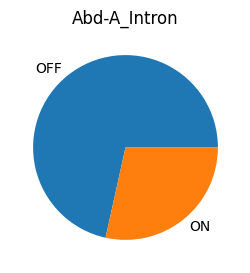

In [220]:
gene_names = transc_data.columns[1:].tolist()

fig, axs = plt.subplots(1, 1, figsize=(3, 3))

for i, gene in enumerate(gene_names):
    axs.pie(dataset[gene].value_counts(), labels=['OFF', 'ON'])
    axs.set_title(f"{gene}")


### Preprocess data

In [221]:
dataset[gene].value_counts()

Abd-A_Intron
0    1641
1     653
Name: count, dtype: int64

##### Will use data from Abd-A gene, which is the gene yielding best results in paper (1641 OFF vs 653 ON)

In [222]:
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber')


In [223]:
dataset

,cellNumber,1-2,1-3,1-4,1-5,1-6,1-7,1-8,1-9,1-10,...,48-50,48-51,48-52,49-50,49-51,49-52,50-51,50-52,51-52,Abd-A_Intron
0,2.0,244.073929,156.705215,227.523438,298.594910,284.360779,319.927277,374.712128,263.243683,307.865479,...,158.210205,205.904953,89.207565,190.698318,243.541779,129.752823,129.892990,114.832573,134.459518,0
1,3.0,262.981628,149.599136,223.714142,298.312103,284.214844,319.122009,373.181580,263.169769,307.152435,...,148.777985,164.663910,56.323582,173.666397,188.108734,68.595428,74.033485,109.178902,135.220947,0
2,13.0,124.413574,62.232868,257.654388,220.720657,246.008240,441.668243,756.308289,263.075958,348.715790,...,359.092010,261.710297,175.725861,371.491577,260.087463,185.764450,168.830246,186.105453,112.900101,0
3,19.0,69.282951,138.565903,207.848846,443.208252,238.614304,273.902191,251.590515,290.168945,330.703491,...,247.873260,371.809601,341.640991,123.936684,247.873001,247.677017,123.936325,191.545700,206.775375,0
4,20.0,140.162399,280.324799,189.418167,158.130585,214.382599,314.234467,237.620895,364.475861,219.858322,...,26.428993,203.600006,384.076782,189.821518,270.037781,418.468781,180.703522,361.407043,180.703522,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2289,54296.0,100.621590,128.352631,286.576843,248.898636,218.128952,296.315460,379.651459,443.508423,539.908630,...,162.532089,142.924255,298.095154,138.703461,180.236008,301.980347,264.441345,421.862579,191.273575,1
2290,54298.0,90.672394,92.193672,265.648987,275.079193,197.236557,120.854897,159.037033,203.947113,274.588165,...,250.285370,146.688385,377.458160,144.669647,342.024048,612.465637,284.677338,569.354797,284.677460,1
2291,54310.0,223.677322,447.354645,531.770569,423.878387,492.909790,394.430939,300.274506,216.164169,359.377045,...,171.912140,257.868195,343.824280,85.956055,171.912109,257.868195,85.956055,171.912140,85.956085,1
2292,54333.0,45.941437,91.882996,295.733276,1146.179077,871.597900,598.217834,329.046478,502.175598,409.138489,...,160.223740,155.931351,269.772308,62.877518,141.710861,293.308624,157.828156,315.656555,157.828400,1


In [185]:
#dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber').iloc[:, 1:]
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber')

X = dataset.iloc[:, 1:-1].to_numpy()
cellNumbers = dataset.iloc[:, 0].to_numpy()
Y = dataset.iloc[:, -1].to_numpy()

# Include cell ID
X = np.hstack((X, np.reshape(cellNumbers, (cellNumbers.shape[0], 1))))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Scale data
scaler = StandardScaler()

###########################
# Balance training dataset
###########################

X0 = X_train[y_train == 0]
X1 = X_train[y_train == 1]

# downsample majority class
X0_down = resample(X0, replace=False, n_samples=len(X1), random_state=42)

# combine
X_train = np.concatenate([X0_down, X1])#.tolist()
y_train = np.concatenate(
    [np.zeros(len(X1), dtype=int), np.ones(len(X1), dtype=int)]
)#.tolist()
###########################

cellNumbers_train = X_train[:, -1]
cellNumbers_test = X_test[:, -1]

# Standardize
X_train = scaler.fit_transform(X_train[:, :-1])
X_test = scaler.transform(X_test[:, :-1])


### Create model - use grid search for hyperparameter tuning

In [7]:
# Define parameter search
param_grid = {
    'class_weight': ['balanced'],
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [100, 150, 200, 300, 400, 500],
}

In [8]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
# Define model
random_forest_model = RandomForestClassifier(random_state=42)

In [10]:
# Initialize model with grid search
grid_search_random_forest_model = GridSearchCV(estimator=random_forest_model,
                                               param_grid = param_grid,
                                               cv=cv,
                                               scoring='f1_weighted',
                                               n_jobs=-1,
                                               verbose=2)

In [186]:
# Define model - avoiding hyperparameter tuning (for balanced dataset just used tuned params)
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced',
                                             max_depth = 5, max_features = 'sqrt',
                                             min_samples_leaf = 1, n_estimators = 300)


### Fit model - using entire parameter space

In [187]:
#hist = grid_search_random_forest_model.fit(X_train, y_train)
hist = random_forest_model.fit(X_train, y_train)

### Save hyperparameter tuning results

In [ ]:
joblib.dump(grid_search_random_forest_model, "../results/random_forest_Mateo/gridsearch_results_random_forest_unfiltered.pkl")

grid_search_df = pd.DataFrame(grid_search_random_forest_model.cv_results_)
grid_search_df.to_csv("../results/random_forest_Mateo/gridsearch_results_random_forest_unfiltered.tsv", index=False, sep='\t')

In [ ]:
print('The best hyperparameters found using 5-fold cross-validation are:')
print(grid_search_random_forest_model.best_params_)

with open('../results/random_forest_Mateo/hyperparams_unfiltered.txt', 'w') as f:
    f.write('The best hyperparameters found using 5-fold cross-validation are:\n')
    for key in grid_search_random_forest_model.best_params_:
        f.write(f"{key}: {grid_search_random_forest_model.best_params_[key]}\n")

The best hyperparameters found using 5-fold cross-validation are:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


### Calculate predictions and plot metrics

In [188]:
# Select best model
#best_model = grid_search_random_forest_model.best_estimator_
best_model = random_forest_model

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

# Calculate predictions on training dataset
y_pred_train = best_model.predict(X_train)
y_pred_train_scores = best_model.predict_proba(X_train)[:,1]


In [189]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)
roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
roc_df.to_csv(f'../results/random_forest_Mateo/ROC_75_5000_balanced.tsv', sep='\t')

# training ROC
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_train_scores)
auc_train = roc_auc_score(y_train, y_pred_train_scores)

In [190]:
# Print classification report
print(class_report)

with open('../results/random_forest_Mateo/classification_report_75_5000_balanced.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.83      0.74      0.78       328
           1       0.49      0.63      0.55       131

    accuracy                           0.71       459
   macro avg       0.66      0.69      0.67       459
weighted avg       0.74      0.71      0.72       459



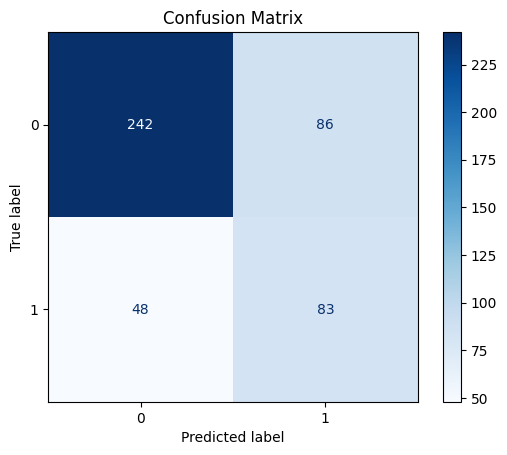

In [191]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_75_5000_balanced.pdf', format='pdf')

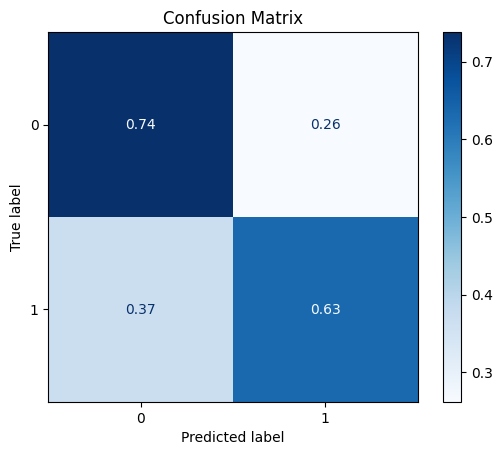

In [192]:
# Normalized confusion matrix
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, None]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_normalized_75_5000_balanced.pdf', format='pdf')

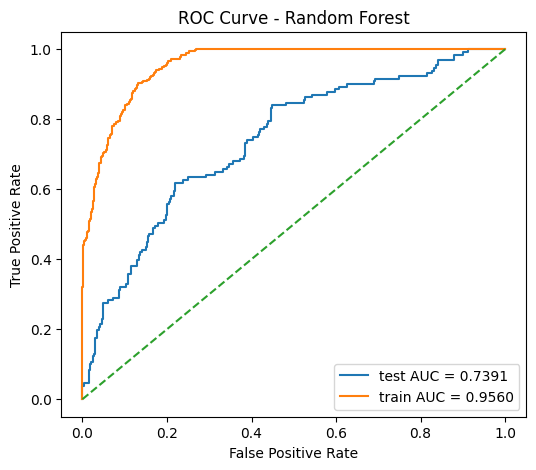

In [193]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"test AUC = {auc:.4f}")
plt.plot(fpr_train, tpr_train, label=f"train AUC = {auc_train:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/random_forest_Mateo/ROC_75_5000_balanced.pdf', format='pdf')

In [194]:
# Get feture importances
n_feats = 20
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:n_feats]
features = dataset.columns[:-1]

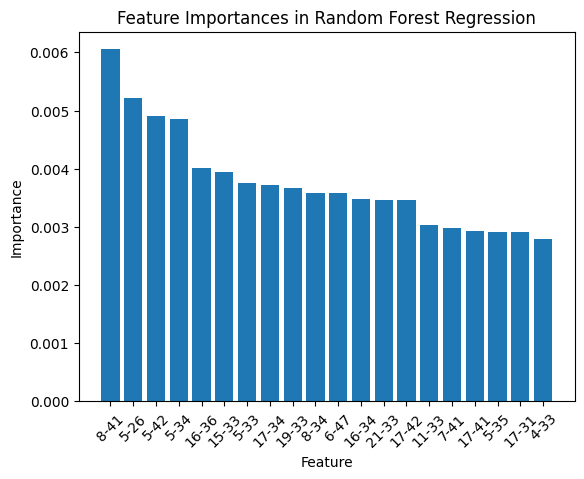

In [195]:
# Plot feature importances
plt.bar(range(n_feats), importances[indices],  align="center")
plt.xticks(range(n_feats), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

plt.savefig('../results/random_forest_Mateo/feature_importance_75_5000_balanced.pdf', format='pdf')

### Get properly predicted data

In [ ]:
# Predictions and labels
prediction_data = pd.DataFrame(X_test)
prediction_data['cellNumber'] = cellNumbers_test
prediction_data['predictions'] = y_pred
prediction_data['true_labels'] = y_test

In [ ]:
# Save properly predicted cellNumbers
prediction_data = prediction_data.iloc[:,-3:]
prediction_data = prediction_data[prediction_data['predictions'] == prediction_data['true_labels']]

In [207]:
# Save predictions
prediction_data.to_csv('../results/random_forest_Mateo/good_predictions_75_5000_balanced.tsv', sep='\t', )

In [208]:
prediction_data

,cellNumber,predictions,true_labels
1,54028.0,1,1
4,2309.0,0,0
5,50154.0,0,0
6,22831.0,1,1
8,49699.0,0,0
...,...,...,...
450,16698.0,1,1
451,28250.0,0,0
453,10684.0,0,0
456,4301.0,0,0


## Train on ORCA data from Mateo et al. (2019) using simulations

### Read data

In [232]:
# Read distance matrices with transcriptional information
dists_path = '../data/Mateo_2019/simulated_dataset/matrices_transformed_classified/'

mats_vector = []
mat_names = []
for state in ['active', 'inactive']:
    mats = os.listdir(f"{dists_path}/{state}")
    
    for mat_i_name in mats:
        mat_i = pd.read_csv(f"{dists_path}/{state}/{mat_i_name}", sep='\t', header=None).to_numpy()
        
        mat_i_vector = []
        for i in range(0, mat_i.shape[0]):
            for j in range(i+ 1, mat_i.shape[1]):
                mat_i_vector.append(mat_i[i,j])

        if state == 'active':
            mat_i_vector.append(1)
        else:
            mat_i_vector.append(0)
        
        mat_names.append(mat_i_name.split('_')[1].split('.')[0])

        mats_vector.append(mat_i_vector)
        
mats_vector = pd.DataFrame(mats_vector)
mats_vector['struct_name'] = mat_names

cols = mats_vector.columns
cols = [cols[-1]] + cols[:-1].tolist()

mats_vector = mats_vector[cols]


In [233]:
mats_vector

,struct_name,0,1,2,3,4,5,6,7,8,...,1369,1370,1371,1372,1373,1374,1375,1376,1377,1378
0,639014,64.604959,215.675166,235.388461,304.482587,332.783853,350.545337,340.395918,204.354659,209.624550,...,144.824410,147.752127,186.397994,114.961695,111.253253,244.171613,89.978508,312.680195,330.441679,1
1,487024,50.747098,153.217199,232.070382,235.193280,297.846428,241.243896,255.492119,329.270592,343.518816,...,121.988216,156.535279,228.752302,60.506155,84.903798,174.882306,40.402497,166.294336,153.997924,1
2,570862,95.248399,203.183572,121.988216,181.518465,271.496973,295.504254,333.759759,321.658528,344.104359,...,128.234013,147.556946,290.819907,30.838621,76.706190,218.212521,77.096552,203.769116,171.173864,1
3,430513,97.785754,141.506330,154.778648,299.212696,286.721103,330.246498,349.569431,225.043861,238.706541,...,112.424340,262.518641,393.875551,75.535103,198.108863,333.954940,186.983537,328.294687,187.959443,1
4,170505,86.074885,110.082166,165.903974,175.663031,200.646217,201.231761,267.788531,276.181321,309.362115,...,206.111290,270.130705,490.685399,114.571332,198.499225,427.837071,132.137635,351.911605,229.923389,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,626139,103.836369,146.190678,132.918360,349.959794,333.564577,135.846077,158.487090,188.154624,112.229159,...,169.417234,169.222053,261.737916,92.125501,69.289307,206.696833,67.923039,116.718325,177.614842,0
2186,64184,51.723004,70.850756,160.634083,152.241293,128.038831,193.034153,171.564227,246.513787,223.872774,...,175.467850,218.993245,215.870347,127.453288,180.737741,152.826837,67.337495,193.814877,232.265563,0
2187,666521,123.159303,203.573935,268.764437,417.297289,368.502002,316.778999,425.104535,327.318781,325.562150,...,116.913506,43.330214,268.764437,89.197783,84.903798,315.217550,86.660429,321.072984,285.159653,0
2188,1020108,213.528173,336.882657,529.721629,747.153425,916.375478,965.561126,995.423841,962.633409,889.635661,...,162.976256,141.896693,264.860814,80.219451,71.826661,204.549840,37.474780,203.183572,195.766689,0


### Check data distribution

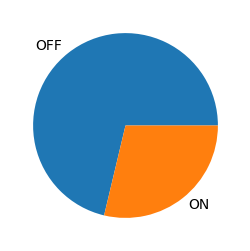

In [5]:
# Plot distribution
fig, axs = plt.subplots(1, 1, figsize=(3, 3))

axs.pie(mats_vector.iloc[:, -1].value_counts(), labels=['OFF', 'ON'])

plt.show()


### Preprocess data

In [234]:
mats_vector[1378].value_counts()

1378
0    1561
1     629
Name: count, dtype: int64

##### Will use data from Abd-A gene, which is the gene yielding best results in paper (1641 OFF vs 653 ON)

In [251]:
X = mats_vector.iloc[:, 1:-1].to_numpy()
cellNumbers = mats_vector.iloc[:, 0].to_numpy()
Y = mats_vector.iloc[:, -1].to_numpy()

# Include cell ID
X = np.hstack((X, np.reshape(cellNumbers, (cellNumbers.shape[0], 1))))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Scale data
scaler = StandardScaler()

###########################
# Balance training dataset
###########################

X0 = X_train[y_train == 0]
X1 = X_train[y_train == 1]

# downsample majority class
X0_down = resample(X0, replace=False, n_samples=len(X1), random_state=42)

# combine
X_train = np.concatenate([X0_down, X1])#.tolist()
y_train = np.concatenate(
    [np.zeros(len(X1), dtype=int), np.ones(len(X1), dtype=int)]
)#.tolist()
###########################

cellNumbers_train = X_train[:, -1]
cellNumbers_test = X_test[:, -1]

# Standardize
X_train = scaler.fit_transform(X_train[:, :-1])
X_test = scaler.transform(X_test[:, :-1])


### Create model - use grid search for hyperparameter tuning

In [252]:
# Define model - avoiding hyperparameter tuning (for balanced dataset just used tuned params)
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced',
                                             max_depth = 5, max_features = 'sqrt',
                                             min_samples_leaf = 1, n_estimators = 300)


### Fit model - using entire parameter space

In [253]:
#hist = grid_search_random_forest_model.fit(X_train, y_train)
hist = random_forest_model.fit(X_train, y_train)

### Calculate predictions and plot metrics

In [254]:
# Select best model
#best_model = grid_search_random_forest_model.best_estimator_
best_model = random_forest_model

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

# Calculate predictions on training dataset
y_pred_train = best_model.predict(X_train)
y_pred_train_scores = best_model.predict_proba(X_train)[:,1]


In [255]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)
roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
roc_df.to_csv(f'../results/random_forest_Mateo/classification_report_simulated.tsv', sep='\t')

# training ROC
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_train_scores)
auc_train = roc_auc_score(y_train, y_pred_train_scores)

In [256]:
# Print classification report
print(class_report)

with open('../results/random_forest_Mateo/classification_report_simulated.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.79      0.66      0.72       312
           1       0.40      0.56      0.47       126

    accuracy                           0.63       438
   macro avg       0.59      0.61      0.59       438
weighted avg       0.68      0.63      0.64       438



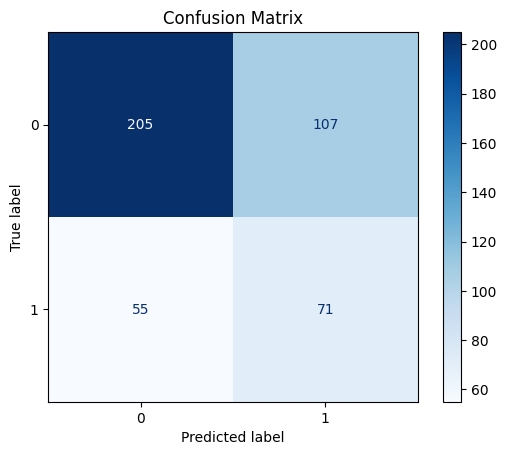

In [257]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_simulated.pdf', format='pdf')

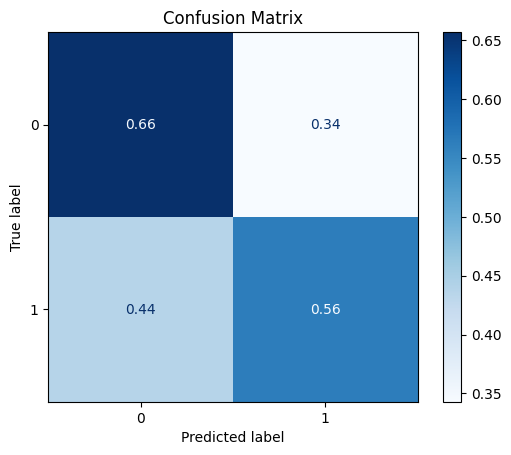

In [258]:
# Normalized confusion matrix
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, None]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_normalized_simulated.pdf', format='pdf')

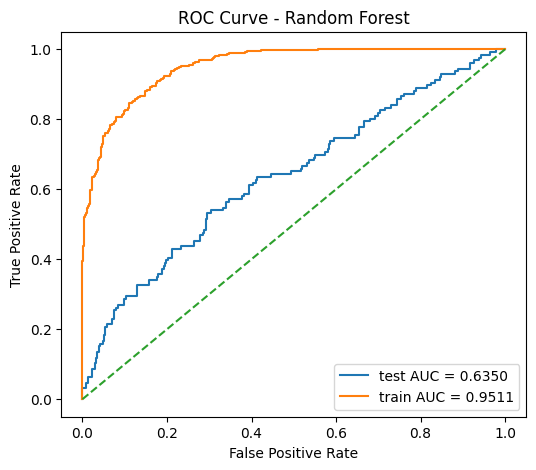

In [259]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"test AUC = {auc:.4f}")
plt.plot(fpr_train, tpr_train, label=f"train AUC = {auc_train:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/random_forest_Mateo/ROC_simulated.pdf', format='pdf')

In [260]:
# Get feture importances
n_feats = 20
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:n_feats]
features = mats_vector.columns[:-1]

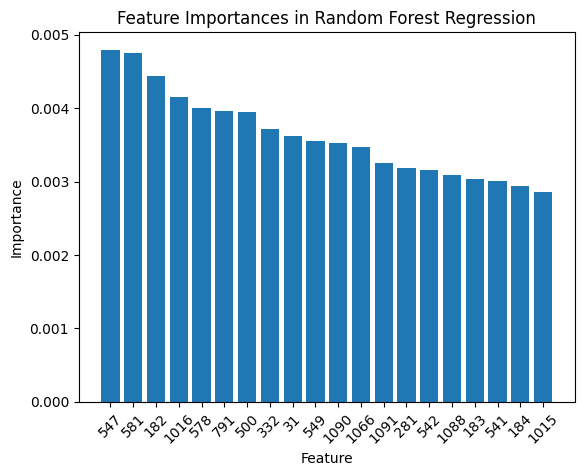

In [261]:
# Plot feature importances
plt.bar(range(n_feats), importances[indices],  align="center")
plt.xticks(range(n_feats), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

plt.savefig('../results/random_forest_Mateo/feature_importance_simulated.pdf', format='pdf')

### Get properly predicted data

In [262]:
# Predictions and labels
prediction_data = pd.DataFrame(X_test)
prediction_data['cellNumber'] = cellNumbers_test
prediction_data['predictions'] = y_pred
prediction_data['true_labels'] = y_test

In [263]:
prediction_data

,0,1,2,3,4,5,6,7,8,9,...,1371,1372,1373,1374,1375,1376,1377,cellNumber,predictions,true_labels
0,0.072089,0.773891,-0.781593,0.082244,-0.606213,-1.038101,-1.102305,-0.261924,-0.286563,-0.773603,...,0.746111,-0.999417,-0.771975,0.367218,0.886684,1.516447,-0.021497,243501,0,0
1,0.060865,1.848969,2.087086,2.136611,2.841006,2.130719,1.254508,0.976457,0.425787,0.790706,...,-0.108437,2.274739,0.547363,0.223329,-0.339054,0.788212,0.178213,1012091,1,0
2,-0.216008,-0.905777,1.612724,1.707237,1.465082,1.017445,0.402532,0.778609,0.565369,-0.180899,...,-0.208437,-0.276057,-0.372916,1.249881,-0.343224,2.144417,2.450477,958610,1,0
3,0.435018,0.462504,0.563587,0.089148,-0.178730,-0.003842,-0.811474,-0.398708,-0.398470,-0.323433,...,-0.321165,0.623384,-0.324052,-0.648596,0.328014,-0.623401,-0.891349,514343,0,0
4,-0.766013,-0.517113,-0.452656,-1.012589,-1.062194,-1.117115,-0.965940,-0.380388,-0.256481,-0.272359,...,-0.315710,-0.356959,-0.296905,0.130982,0.865838,0.089002,-0.594002,91615,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,-0.264648,-0.353464,-0.492475,0.678673,0.703594,0.971452,0.851449,0.579540,-0.096443,0.269270,...,-0.833893,-0.285575,-0.049868,-1.548440,-0.976938,-1.280395,-0.882473,854012,1,1
434,-0.429275,-1.233074,-0.958181,-1.312184,-1.067894,-1.082915,-1.445026,-1.176665,-1.825576,-1.685819,...,-0.037528,-0.723398,-1.171034,-0.848323,-1.685698,-0.950579,-1.055555,21977,0,0
435,-0.971797,-0.798951,-1.309624,-1.145129,-1.254846,-1.233867,-1.315902,-1.065528,-1.186627,-1.204767,...,0.467928,0.594831,0.259606,0.156753,-0.163949,-0.103611,-0.798150,45640,0,1
436,0.494882,-0.442107,-0.514981,-0.127610,0.046981,-0.076959,0.129803,0.303530,0.103304,0.264519,...,-0.719348,-0.671049,-1.114026,0.019307,-1.260442,-0.019178,0.479998,725407,0,1


In [264]:
# Save properly predicted cellNumbers
prediction_data = prediction_data.iloc[:,-3:]
prediction_data = prediction_data[prediction_data['predictions'] == prediction_data['true_labels']]

In [265]:
# Save predictions
prediction_data.to_csv('../results/random_forest_Mateo/good_predictions_75_5000_balanced_simulated.tsv', sep='\t', )

In [266]:
prediction_data

,cellNumber,predictions,true_labels
0,243501,0,0
3,514343,0,0
4,91615,0,0
5,954508,0,0
6,863505,0,0
...,...,...,...
429,268580,0,0
430,701526,0,0
432,335262,0,0
433,854012,1,1
